# Eksploracja i Wizualizacja Danych za pomocą KNIME oraz Python (Wariant 13)

## Cel Zajęć
Celem laboratorium jest zapoznanie się z narzędziem **KNIME Analytics Platform** (lub alternatywnie językiem Python) w celu wczytania, oczyszczenia, przetworzenia i zwizualizowania danych z dużych zbiorów. 

W ramach tego laboratorium realizowany jest **Wariant 13**: 
**Global Burden of Disease Study 2019 (GBD 2019) Relative Risks** (Ryzyka względne przypisane do różnych czynników ryzyka i wyników zdrowotnych według wieku i płci).

Plik źródłowy: `relative_risks.xlsx`

# Część 2: Implementacja i Wizualizacja w Python

Poniższy kod wczytuje i oczyszcza dane w identyczny sposób, jak opisany pipeline KNIME, a następnie generuje wymagane wizualizacje.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Ustawienia wykresów
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

### 1. Wczytanie i czyszczenie danych (odpowiednik kroków 1-4 z KNIME)

In [2]:
# Wczytanie pliku Excel
df = pd.read_excel("relative_risks.xlsx", header=None)

# Wyciągnięcie nagłówków kolumn i podnagłówków (grupy wiekowe)
headers = list(df.iloc[1])
sub_headers = list(df.iloc[2])
age_columns = sub_headers[4:28]

# Przetwarzanie wierszy
records = []
current_risk = None

for idx, row in df.iloc[3:].iterrows():
    val_0 = row[0]
    val_1 = row[1]
    
    # Jeśli val_0 nie jest puste, a val_1 jest puste -> to jest nowy czynnik ryzyka (Risk Factor)
    if pd.notna(val_0) and pd.isna(val_1):
        current_risk = val_0
        continue
        
    # Jeśli val_1 nie jest puste -> to jest wiersz z danymi
    if pd.notna(val_1):
        outcome = val_0
        category = row[1]
        morbidity_mortality = row[2]
        sex = row[3]
        
        record = {
            "Risk": current_risk,
            "Outcome": outcome,
            "Category_Units": category,
            "Morbidity_Mortality": morbidity_mortality,
            "Sex": sex
        }
        
        # Zapisanie surowych wartości grup wiekowych
        for i, col_idx in enumerate(range(4, 28)):
            age_name = age_columns[i]
            record[age_name] = row[col_idx]
            
        records.append(record)

cleaned_df = pd.DataFrame(records)
print(f"Rozmiar przetworzonej ramki danych: {cleaned_df.shape}")
cleaned_df.head()

Rozmiar przetworzonej ramki danych: (2231, 29)


,Risk,Outcome,Category_Units,Morbidity_Mortality,Sex,All-age,0-6 days,7-27 days,28-364 days,1-4 years,...,50-54 years,55-59 years,60-64 years,65-69 years,70-74 years,75-79 years,80-84 years,85-89 years,90-94 years,95+ years
0,Unsafe water source,Diarrhoeal diseases,"Unimproved, untreated",Both,Both,11.084\n(4.287 to 22.867),NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Unsafe water source,Diarrhoeal diseases,"Unimproved, chlorinated",Both,Both,8.024\n(3.203 to 16.486),NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Unsafe water source,Diarrhoeal diseases,"Unimproved, filter",Both,Both,5.331\n(2.153 to 10.887),NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Unsafe water source,Diarrhoeal diseases,"Improved, untreated",Both,Both,8.986\n(3.898 to 17.446),NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Unsafe water source,Diarrhoeal diseases,"Improved, chlorinated",Both,Both,6.505\n(2.905 to 12.528),NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2. Konwersja wartości tekstowych na liczbowe (odpowiednik kroków 5-6 z KNIME)

Wyodrębniamy samą estymatę ryzyka względnego (RR) z formatu tekstowego, np. z `11.084\n(4.287 to 22.867)` wyciągamy `11.084` i konwertujemy na typ `float`.

In [3]:
def extract_numeric_rr(val):
    if pd.isna(val):
        return np.nan
    val_str = str(val).strip()
    if not val_str:
        return np.nan
    # Podział po znaku nowej linii lub spacji
    parts = re.split(r'[\n\s]+', val_str)
    try:
        return float(parts[0])
    except ValueError:
        return np.nan

# Konwersja kolumn wiekowych
for col in age_columns:
    cleaned_df[col] = cleaned_df[col].apply(extract_numeric_rr)

cleaned_df.head()

,Risk,Outcome,Category_Units,Morbidity_Mortality,Sex,All-age,0-6 days,7-27 days,28-364 days,1-4 years,...,50-54 years,55-59 years,60-64 years,65-69 years,70-74 years,75-79 years,80-84 years,85-89 years,90-94 years,95+ years
0,Unsafe water source,Diarrhoeal diseases,"Unimproved, untreated",Both,Both,11.084,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Unsafe water source,Diarrhoeal diseases,"Unimproved, chlorinated",Both,Both,8.024,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Unsafe water source,Diarrhoeal diseases,"Unimproved, filter",Both,Both,5.331,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Unsafe water source,Diarrhoeal diseases,"Improved, untreated",Both,Both,8.986,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Unsafe water source,Diarrhoeal diseases,"Improved, chlorinated",Both,Both,6.505,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3. Wizualizacja: Histogram (odpowiednik kroku 7 z KNIME)

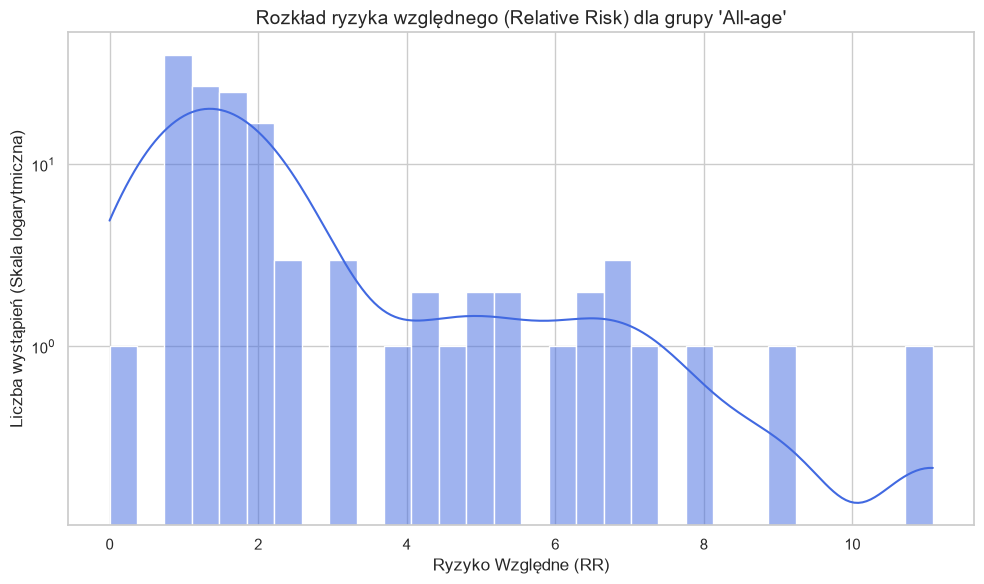

In [4]:
plt.figure(figsize=(10, 6))
all_age_data = cleaned_df['All-age'].dropna()
sns.histplot(all_age_data, bins=30, kde=True, color='royalblue')
plt.yscale('log')  # Skala logarytmiczna z uwagi na duże różnice w wartościach ryzyk
plt.title("Rozkład ryzyka względnego (Relative Risk) dla grupy 'All-age'", fontsize=14)
plt.xlabel("Ryzyko Względne (RR)", fontsize=12)
plt.ylabel("Liczba wystąpień (Skala logarytmiczna)", fontsize=12)
plt.tight_layout()
plt.show()

### 4. Wizualizacja: Wykres punktowy (Scatter Plot)

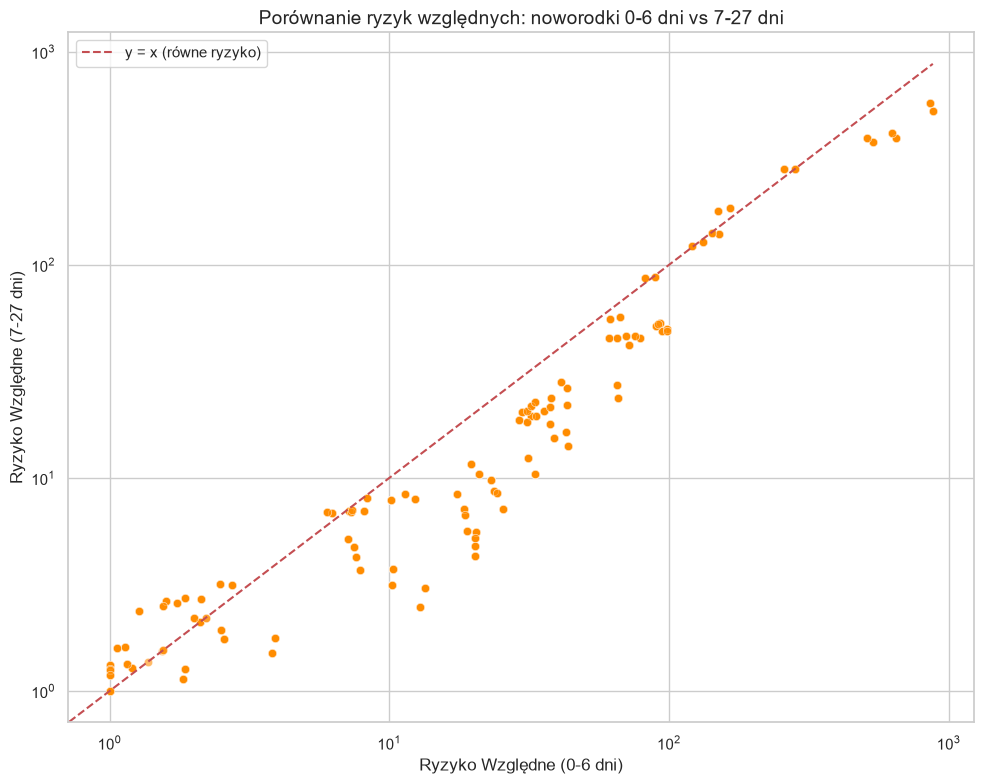

In [5]:
plt.figure(figsize=(10, 8))
scatter_data = cleaned_df[['0-6 days', '7-27 days']].dropna()

sns.scatterplot(data=scatter_data, x='0-6 days', y='7-27 days', alpha=0.6, color='darkorange')

# Linia y = x (równe ryzyko)
max_val = max(scatter_data['0-6 days'].max(), scatter_data['7-27 days'].max())
plt.plot([0, max_val], [0, max_val], 'r--', label='y = x (równe ryzyko)')

plt.xscale('log')
plt.yscale('log')
plt.title("Porównanie ryzyk względnych: noworodki 0-6 dni vs 7-27 dni", fontsize=14)
plt.xlabel("Ryzyko Względne (0-6 dni)", fontsize=12)
plt.ylabel("Ryzyko Względne (7-27 dni)", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

### 5. Dodatkowa Analiza: Przykład wpływu jakości wody na ryzyko chorób biegunkowych

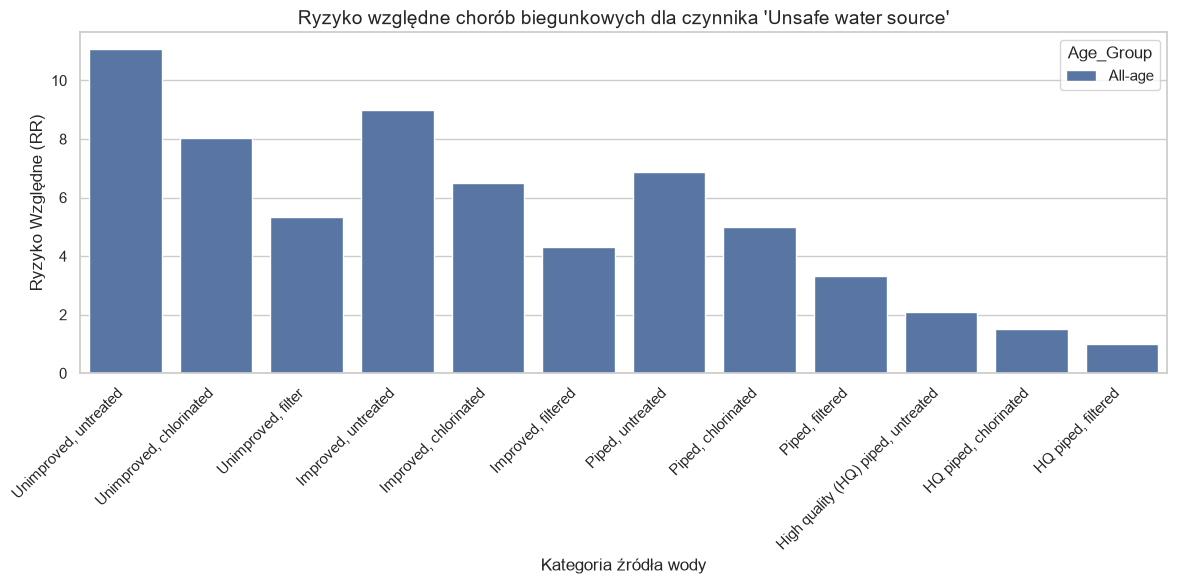

In [6]:
water_df = cleaned_df[
    (cleaned_df['Risk'] == 'Unsafe water source') & 
    (cleaned_df['Outcome'] == 'Diarrhoeal diseases')
].copy()

# Meltowanie kolumn wiekowych do prostszej analizy
melted_water = water_df.melt(
    id_vars=['Category_Units', 'Sex'], 
    value_vars=['All-age', '0-6 days', '7-27 days', '28-364 days', '1-4 years'],
    var_name='Age_Group', 
    value_name='Relative_Risk'
).dropna()

plt.figure(figsize=(12, 6))
sns.barplot(data=melted_water, x='Category_Units', y='Relative_Risk', hue='Age_Group')
plt.xticks(rotation=45, ha='right')
plt.title("Ryzyko względne chorób biegunkowych dla czynnika 'Unsafe water source'", fontsize=14)
plt.xlabel("Kategoria źródła wody", fontsize=12)
plt.ylabel("Ryzyko Względne (RR)", fontsize=12)
plt.tight_layout()
plt.show()

## Wnioski z analizy danych:
1. **Rozkład Ryzyk Względnych (Histogram)**: Większość ryzyk względnych koncentruje się wokół wartości `1.0` (brak wpływu czynnika ryzyka na wynik zdrowotny w porównaniu z grupą referencyjną). Jednakże istnieje długa prawostronna końcówka (wartości > 10, a nawet > 100), co wskazuje na ekstremalnie silny wpływ niektórych czynników ryzyka na określone schorzenia.
2. **Porównanie Grup Wiekowych (Scatter Plot)**: Korelacja między ryzykami dla grup wiekowych `0-6 days` i `7-27 days` jest bardzo silna (punkty układają się blisko linii `y = x`). Oznacza to, że wpływ czynników ryzyka na noworodki w pierwszym miesiącu życia pozostaje bardzo podobny.
3. **Wpływ jakości wody**: Wykres słupkowy pokazuje wyraźnie, że wraz z polepszaniem się standardu wody (od *Unimproved, untreated* do *HQ piped, filtered*), ryzyko względne chorób biegunkowych spada z poziomu ponad 11.0 do 1.0 (wartość referencyjna).